# BookWise — E-Commerce Book Pricing & Rating Analytics

## 5. Machine Learning

### Objective

Build machine learning models using the processed BookWise dataset to identify patterns and predict important book-related outcomes.



In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA

### Load the Cleaned Dataset

In [62]:
df = pd.read_csv("../data/cleaned_books.csv")

df.head()

,Title,Price,Rating,Availability,Link,Category,Description,UPC,Product Type,Tax,Number Available,Number of Reviews,Stock_Quantity,Rating_Category,Title_Length,Description_Length,Description_Word_Count,Price_Band,Stock_Status
0,A Light in the Attic,51.77,3,In stock,a-light-in-the-attic_1000/index.html,Poetry,It's hard to imagine a world without A Light i...,a897fe39b1053632,Books,0.0,In stock (22 available),0,22,Average,20,1017,164,Premium,High Stock
1,Tipping the Velvet,53.74,1,In stock,tipping-the-velvet_999/index.html,Historical Fiction,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,Books,0.0,In stock (20 available),0,20,Low,18,1029,165,Premium,High Stock
2,Soumission,50.10,1,In stock,soumission_998/index.html,Fiction,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,Books,0.0,In stock (20 available),0,20,Low,10,1093,163,Premium,High Stock
3,Sharp Objects,47.82,4,In stock,sharp-objects_997/index.html,Mystery,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,Books,0.0,In stock (20 available),0,20,High,13,1635,274,Premium,High Stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,sapiens-a-brief-history-of-humankind_996/index...,History,From a renowned historian comes a groundbreaki...,4165285e1663650f,Books,0.0,In stock (20 available),0,20,High,37,1945,304,Premium,High Stock


In [63]:
df.shape

(1000, 19)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   1000 non-null   str    
 1   Price                   1000 non-null   float64
 2   Rating                  1000 non-null   int64  
 3   Availability            1000 non-null   str    
 4   Link                    1000 non-null   str    
 5   Category                1000 non-null   str    
 6   Description             1000 non-null   str    
 7   UPC                     1000 non-null   str    
 8   Product Type            1000 non-null   str    
 9   Tax                     1000 non-null   float64
 10  Number Available        1000 non-null   str    
 11  Number of Reviews       1000 non-null   int64  
 12  Stock_Quantity          1000 non-null   int64  
 13  Rating_Category         1000 non-null   str    
 14  Title_Length            1000 non-null   int64  
 15 

In [65]:
df.isnull().sum()

Title                     0
Price                     0
Rating                    0
Availability              0
Link                      0
Category                  0
Description               0
UPC                       0
Product Type              0
Tax                       0
Number Available          0
Number of Reviews         0
Stock_Quantity            0
Rating_Category           0
Title_Length              0
Description_Length        0
Description_Word_Count    0
Price_Band                0
Stock_Status              0
dtype: int64

### Feature Selection for Clustering

The following numerical features are selected for book segmentation:

- Price
- Rating
- Stock Quantity
- Title Length
- Description Length
- Description Word Count

Derived categorical features such as Price Band, Rating Category, and Stock Status are excluded to prevent data leakage.

In [66]:
cluster_features = [
    "Price",
    "Rating",
    "Stock_Quantity",
    "Title_Length",
    "Description_Length",
    "Description_Word_Count"
]

X_cluster = df[cluster_features].copy()

X_cluster.head()

,Price,Rating,Stock_Quantity,Title_Length,Description_Length,Description_Word_Count
0,51.77,3,22,20,1017,164
1,53.74,1,20,18,1029,165
2,50.10,1,20,10,1093,163
3,47.82,4,20,13,1635,274
4,54.23,5,20,37,1945,304


### Check Clustering Features

In [67]:
print("Clustering dataset shape:", X_cluster.shape)
print("\nMissing values:")
print(X_cluster.isnull().sum())

Clustering dataset shape: (1000, 6)

Missing values:
Price                     0
Rating                    0
Stock_Quantity            0
Title_Length              0
Description_Length        0
Description_Word_Count    0
dtype: int64


###  Feature Scaling

The selected features have different numerical ranges. Standardization is applied so that features with larger numerical values do not dominate the clustering process.

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (1000, 6)


### Determine the Optimal Number of Clusters

The Elbow Method and Silhouette Score will be used to evaluate different numbers of clusters.

The Elbow Method examines the reduction in within-cluster variation, while the Silhouette Score measures how well-separated and cohesive the resulting clusters are.

In [69]:
inertia_values = []
silhouette_values = []
davies_bouldin_values = []
calinski_harabasz_values = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)

    silhouette_values.append(
        silhouette_score(X_scaled, labels)
    )

    davies_bouldin_values.append(
        davies_bouldin_score(X_scaled, labels)
    )

    calinski_harabasz_values.append(
        calinski_harabasz_score(X_scaled, labels)
    )

In [70]:
model_comparison = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values,
    "Davies_Bouldin_Index": davies_bouldin_values,
    "Calinski_Harabasz_Score": calinski_harabasz_values
})

display(model_comparison.round(4))

,K,Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Score
0,2,4929.0319,0.2201,1.8628,216.8430
1,3,4229.0868,0.1872,1.7730,208.7449
2,4,3829.4936,0.1607,1.6563,188.1732
3,5,3463.8189,0.1709,1.6076,182.1328
4,6,3180.5930,0.1829,1.5373,176.2244
5,7,2962.0321,0.1797,1.4481,169.7428
6,8,2755.2829,0.1740,1.3633,166.8877
7,9,2573.6318,0.1848,1.2836,164.9192
8,10,2412.2886,0.1841,1.2290,163.5991


In [71]:
best_silhouette_k = int(
    model_comparison.loc[
        model_comparison["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_db_k = int(
    model_comparison.loc[
        model_comparison["Davies_Bouldin_Index"].idxmin(),
        "K"
    ]
)

best_ch_k = int(
    model_comparison.loc[
        model_comparison["Calinski_Harabasz_Score"].idxmax(),
        "K"
    ]
)

print("Best K by Silhouette:", best_silhouette_k)
print("Best K by Davies-Bouldin:", best_db_k)
print("Best K by Calinski-Harabasz:", best_ch_k)

Best K by Silhouette: 2
Best K by Davies-Bouldin: 10
Best K by Calinski-Harabasz: 2


### Davies-Bouldin 

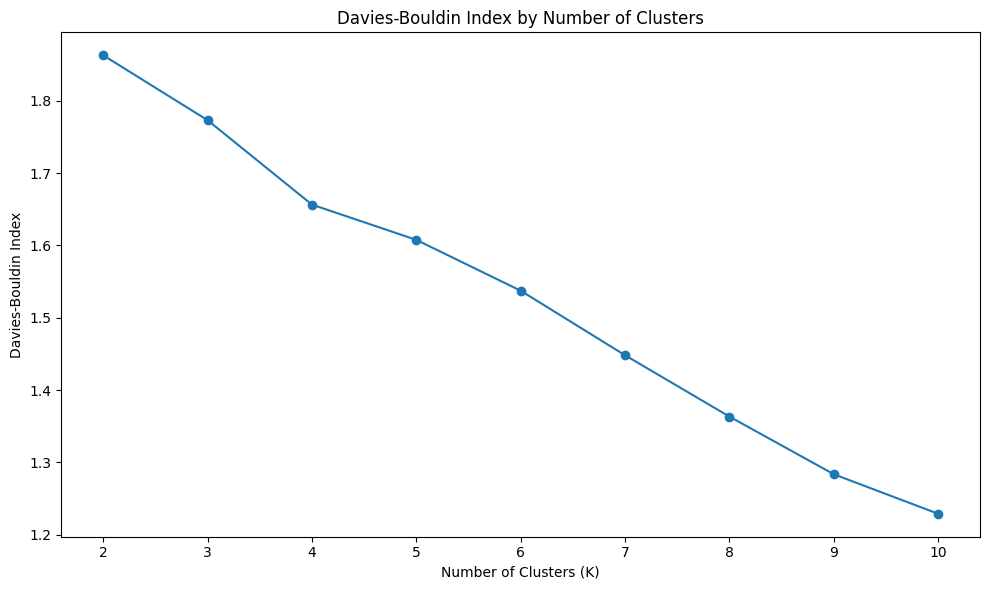

In [72]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    davies_bouldin_values,
    marker="o"
)

plt.title("Davies-Bouldin Index by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(list(k_values))

plt.savefig(
    "../charts/davies_bouldin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Calinski-Harabasz

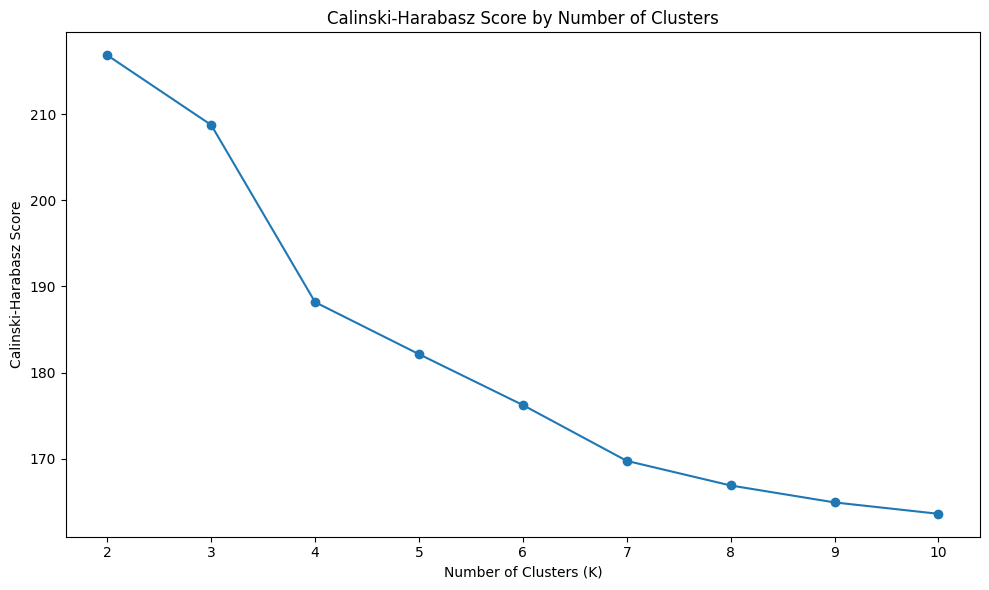

In [73]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    calinski_harabasz_values,
    marker="o"
)

plt.title("Calinski-Harabasz Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values))

plt.savefig(
    "../charts/Calinski_Harabasz.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Elbow Method

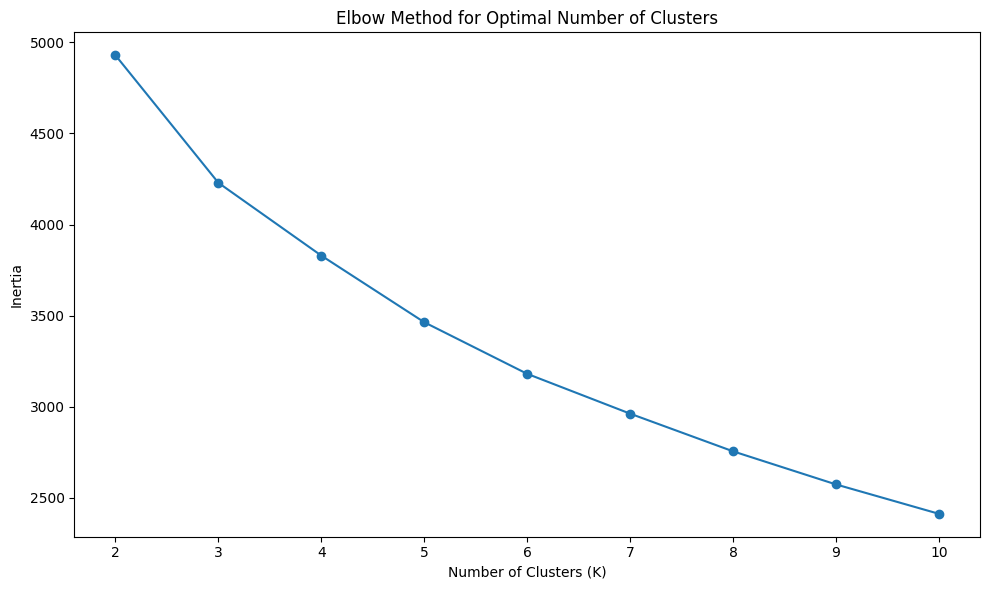

In [74]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()

plt.savefig(
    "../charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Silhouette Score

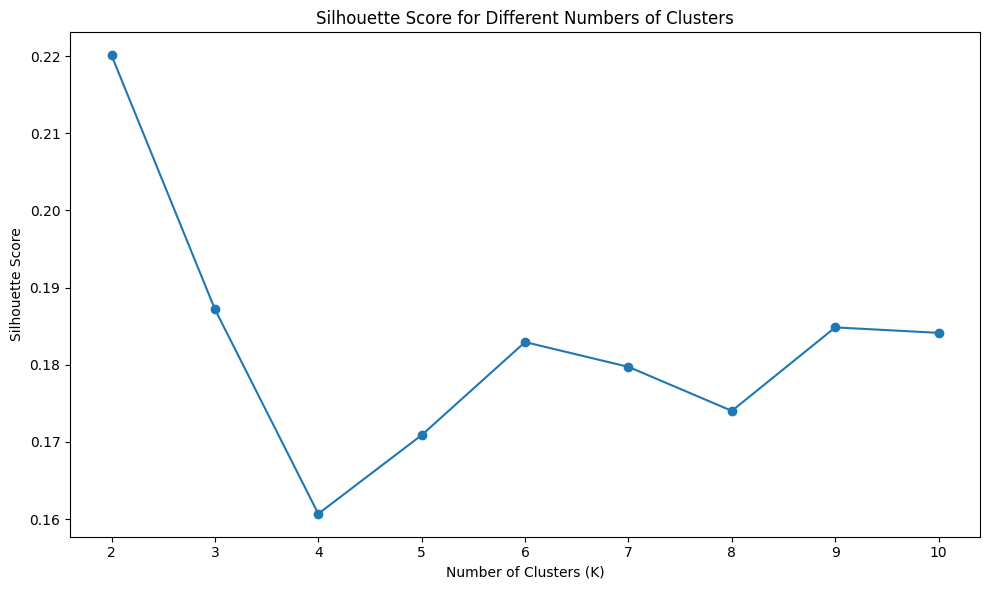

In [75]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.tight_layout()

plt.savefig(
    "../charts/silhouette_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Selection of the Number of Clusters

The Elbow Method does not show a single sharp elbow, while the highest Silhouette Score occurs at K = 2.

Although K = 2 provides the highest numerical Silhouette Score, K = 3 is selected for the final segmentation because it provides a more useful level of business differentiation for an e-commerce book catalog while maintaining a reasonable Silhouette Score.

Therefore, three clusters will be used for the final K-Means segmentation.

In [76]:
optimal_k = 3

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 3


In [77]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

final_db = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

final_ch = calinski_harabasz_score(
    X_scaled,
    cluster_labels
)

print("Final K:", optimal_k)
print("Silhouette Score:", round(final_silhouette, 4))
print("Davies-Bouldin Index:", round(final_db, 4))
print("Calinski-Harabasz Score:", round(final_ch, 4))

Final K: 3
Silhouette Score: 0.1872
Davies-Bouldin Index: 1.773
Calinski-Harabasz Score: 208.7449


### K3 vs K2

In [78]:
comparison_k = model_comparison[
    model_comparison["K"].isin([2, 3])
].copy()

display(comparison_k.round(4))

,K,Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Score
0,2,4929.0319,0.2201,1.8628,216.8430
1,3,4229.0868,0.1872,1.7730,208.7449


### PCA visualization

In [79]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print(
    "PC1 variance:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "PC2 variance:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

PC1 variance: 0.3394
PC2 variance: 0.1795
Total variance explained: 0.519


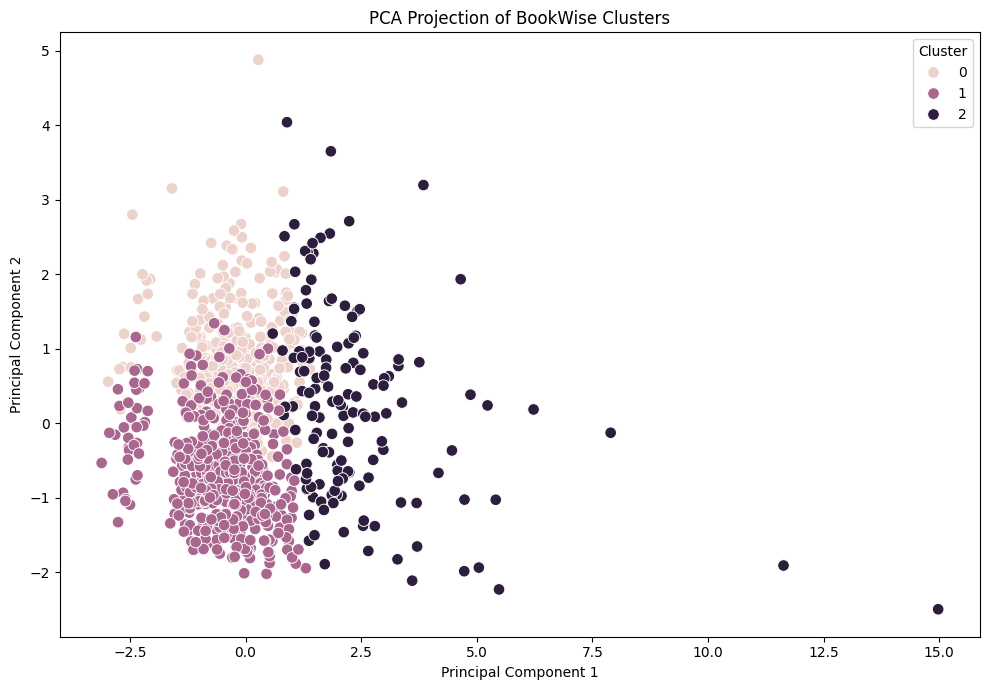

<Figure size 640x480 with 0 Axes>

In [80]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=70
)

plt.title("PCA Projection of BookWise Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

plt.savefig(
    "../charts/PCA_Projection.png",
    dpi=300,
    bbox_inches="tight"
)

In [81]:
stability_labels = []

for seed in range(10):

    model = KMeans(
        n_clusters=optimal_k,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    stability_labels.append(labels)

In [82]:
ari_scores = []

for i in range(1, len(stability_labels)):

    ari = adjusted_rand_score(
        stability_labels[0],
        stability_labels[i]
    )

    ari_scores.append(ari)

print(
    "Mean ARI:",
    round(np.mean(ari_scores), 4)
)

print(
    "Minimum ARI:",
    round(np.min(ari_scores), 4)
)

print(
    "Maximum ARI:",
    round(np.max(ari_scores), 4)
)

Mean ARI: 0.9975
Minimum ARI: 0.9937
Maximum ARI: 1.0


### Train the K-Means Clustering Model


In [83]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster labels generated successfully.")
print("Number of clusters:", len(set(cluster_labels)))

Cluster labels generated successfully.
Number of clusters: 3


###  Add Cluster Labels to the Dataset

In [84]:
df["Cluster"] = cluster_labels

print(df["Cluster"].value_counts().sort_index())

Cluster
0    352
1    497
2    151
Name: count, dtype: int64


### Cluster Profiling

The clusters are profiled using the average values of the numerical features.

This helps identify the characteristics of each book segment and understand how the clusters differ in terms of price, rating, inventory, and content characteristics.

In [85]:
cluster_profile = df.groupby("Cluster")[
    [
        "Price",
        "Rating",
        "Stock_Quantity",
        "Title_Length",
        "Description_Length",
        "Description_Word_Count"
    ]
].mean().round(2)

cluster_profile

,Price,Rating,Stock_Quantity,Title_Length,Description_Length,Description_Word_Count
Cluster,,,,,,
0,34.95,2.93,14.74,37.67,1274.91,210.75
1,35.06,2.88,3.99,33.41,1220.96,203.45
2,35.38,3.04,9.36,61.15,2490.69,404.50


### Cluster Size

The number of books assigned to each cluster is examined to understand the distribution of the book segments.

In [86]:
cluster_sizes = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

Cluster
0    352
1    497
2    151
Name: count, dtype: int64

### Business Interpretation of Book Clusters

The clustering results reveal three distinct book segments:

- **Cluster 0 — High-Stock Books:** Books with relatively high inventory levels and shorter content descriptions.
- **Cluster 1 — Low-Stock Books:** Books with relatively low inventory levels and shorter content descriptions.
- **Cluster 2 — Detailed-Content Books:** Books characterized by substantially longer titles and descriptions, with moderate inventory levels.

The clusters have similar average prices and ratings, indicating that inventory and content characteristics contribute more strongly to the segmentation than price and rating.

In [87]:
cluster_names = {
    0: "High-Stock Books",
    1: "Low-Stock Books",
    2: "Detailed-Content Books"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

cluster_summary = (
    df.groupby("Cluster_Name")
    .agg(
        Number_of_Books=("Title", "count"),
        Average_Price=("Price", "mean"),
        Average_Rating=("Rating", "mean"),
        Average_Stock=("Stock_Quantity", "mean"),
        Average_Title_Length=("Title_Length", "mean"),
        Average_Description_Length=("Description_Length", "mean"),
        Average_Description_Words=("Description_Word_Count", "mean")
    )
    .round(2)
)

cluster_summary

,Number_of_Books,Average_Price,Average_Rating,Average_Stock,Average_Title_Length,Average_Description_Length,Average_Description_Words
Cluster_Name,,,,,,,
Detailed-Content Books,151,35.38,3.04,9.36,61.15,2490.69,404.50
High-Stock Books,352,34.95,2.93,14.74,37.67,1274.91,210.75
Low-Stock Books,497,35.06,2.88,3.99,33.41,1220.96,203.45


### Cluster Distribution

The distribution of books across the three machine-learning segments is visualized to understand the relative size of each segment.

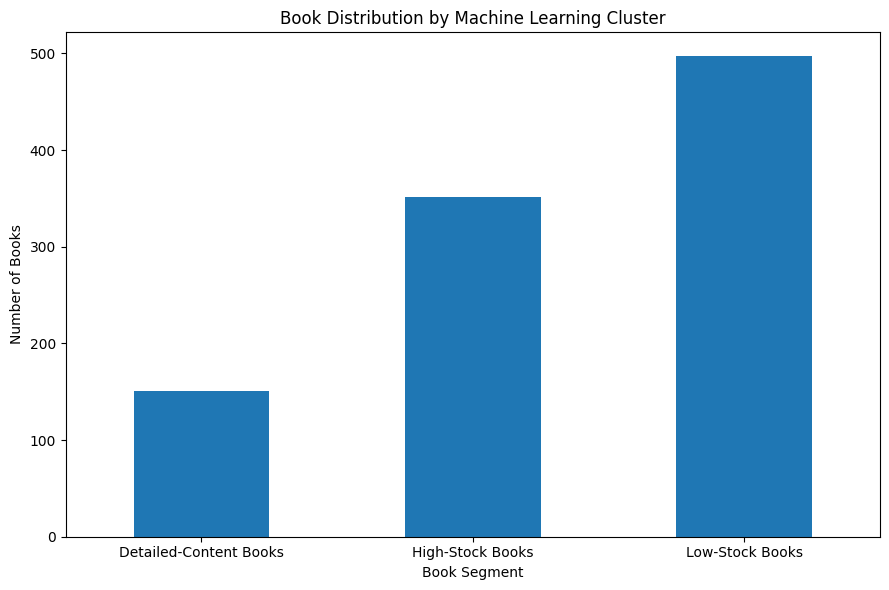

In [88]:
plt.figure(figsize=(9, 6))

cluster_summary["Number_of_Books"].plot(kind="bar")

plt.title("Book Distribution by Machine Learning Cluster")
plt.xlabel("Book Segment")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../charts/book_cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Standardized Cluster Comparison

Because the clustering features have different numerical scales, their raw averages are not directly comparable in a single chart.

The cluster-level feature means are standardized to visualize the relative characteristics of each cluster on a common scale.

In [89]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Price",
    "Rating",
    "Stock_Quantity",
    "Title_Length",
    "Description_Length",
    "Description_Word_Count"
]

cluster_comparison = df.groupby("Cluster")[cluster_features].mean()

cluster_comparison_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_comparison),
    index=cluster_comparison.index,
    columns=cluster_comparison.columns
)

cluster_comparison_scaled

,Price,Rating,Stock_Quantity,Title_Length,Description_Length,Description_Word_Count
Cluster,,,,,,
0,-1.006259,-0.248913,1.224812,-0.525139,-0.660594,-0.667567
1,-0.357442,-1.081169,-1.224678,-0.874608,-0.752621,-0.745923
2,1.363700,1.330081,-0.000133,1.399747,1.413215,1.413490


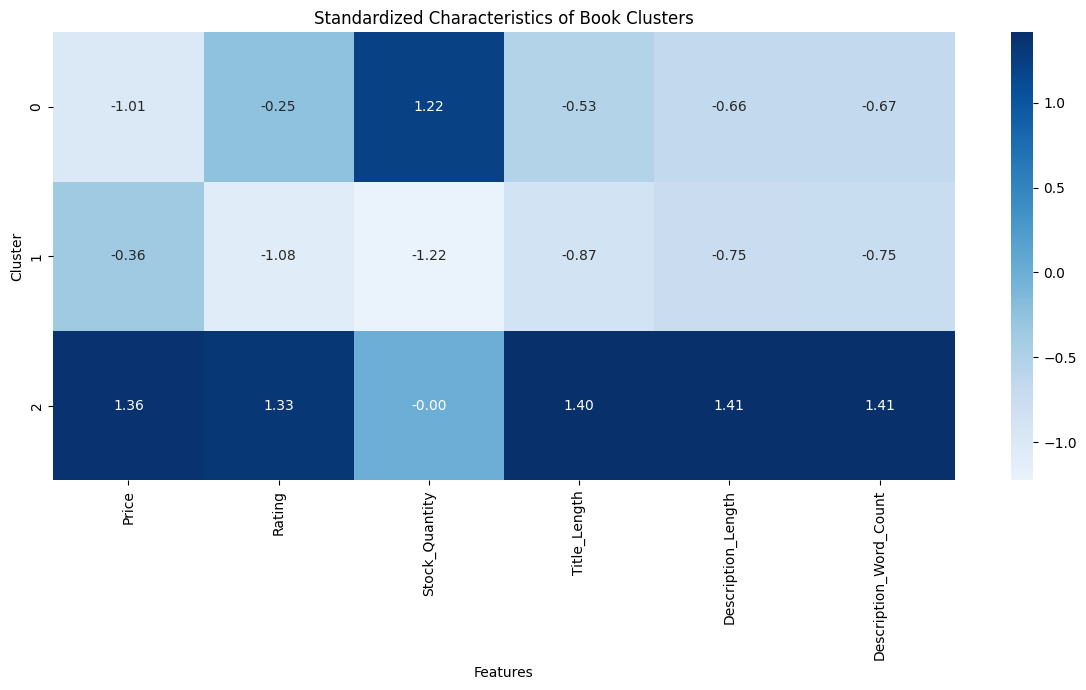

In [90]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_comparison_scaled,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Standardized Characteristics of Book Clusters")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.tight_layout()

plt.savefig(
    "../charts/standardized_cluster_characteristics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Cluster Insights

The K-Means clustering model identified three distinct segments within the book catalog.

Cluster 0 represents High-Stock Books, containing 352 books with an average stock quantity of approximately 14.74.

Cluster 1 represents Low-Stock Books, containing 497 books with an average stock quantity of approximately 3.99.

Cluster 2 represents Detailed-Content Books, containing 151 books with substantially longer titles and descriptions compared with the other clusters.

The average prices and ratings are relatively similar across the clusters, while stock and content-length characteristics show stronger differences.

In [91]:
output_path = "../data/bookwise_clustered_data.csv"
df.to_csv(
    output_path, index=False
)

print("Clustered dataset saved successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Clustered dataset saved successfully.
Shape: (1000, 21)
Columns: ['Title', 'Price', 'Rating', 'Availability', 'Link', 'Category', 'Description', 'UPC', 'Product Type', 'Tax', 'Number Available', 'Number of Reviews', 'Stock_Quantity', 'Rating_Category', 'Title_Length', 'Description_Length', 'Description_Word_Count', 'Price_Band', 'Stock_Status', 'Cluster', 'Cluster_Name']


## Conclusion

K-Means clustering was used to segment the 1,000 books based on price, rating, stock quantity, title length, description length, and description word count.

The analysis identified three meaningful book segments:

- **High-Stock Books:** 352 books with relatively high inventory levels.
- **Low-Stock Books:** 497 books with relatively low inventory levels.
- **Detailed-Content Books:** 151 books with higher average price and rating and substantially longer titles and descriptions.

These segments can support inventory planning, catalog management, and business decision-making.

## Summary
The 
dataset does not contain a reliable supervised target variable for prediction, an unsupervised learning approach was selected.

K-Means clustering was applied to standardized price, rating, inventory and text-based features to identify natural segments within the BookWise catalogue.

The final segmentation was evaluated using multiple clustering metrics and interpreted from a business perspective.

# Final Conclusion

The BookWise Machine Learning analysis focused on discovering meaningful patterns within the book catalog.

K-Means clustering was used to segment books based on price, rating, stock quantity, title length, description length, and description word count.

The analysis identified three distinct segments:

- High-Stock Books
- Low-Stock Books
- Detailed-Content Books

The clustering results provide an additional business perspective that can be used for inventory management, catalog analysis, pricing analysis, and dashboard-based decision-making.

The supervised prediction experiments for stock status, price, and rating showed limited predictive performance with the available features. Therefore, the clustering approach was retained as the primary machine-learning insight rather than relying on weak prediction accuracy.

Overall, the machine-learning stage complements the exploratory analysis by converting the observed book characteristics into actionable customer and inventory segments.